## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read File

In [11]:
data = pd.read_csv("ai_job_market.csv")
data.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


## Dataset Overview

In [22]:
data.shape
print("Rows wise Data:",data.shape[0])
print("Column Wise Data:", data.shape[1])

Rows wise Data: 2000
Column Wise Data: 12


In [7]:
data.columns

Index(['job_id', 'company_name', 'industry', 'job_title', 'skills_required',
       'experience_level', 'employment_type', 'location', 'salary_range_usd',
       'posted_date', 'company_size', 'tools_preferred'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            2000 non-null   int64 
 1   company_name      2000 non-null   object
 2   industry          2000 non-null   object
 3   job_title         2000 non-null   object
 4   skills_required   2000 non-null   object
 5   experience_level  2000 non-null   object
 6   employment_type   2000 non-null   object
 7   location          2000 non-null   object
 8   salary_range_usd  2000 non-null   object
 9   posted_date       2000 non-null   object
 10  company_size      2000 non-null   object
 11  tools_preferred   2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [44]:
data.dtypes
print("Columns Datatypes:")
print(data.dtypes)

Columns Datatypes:
job_id               int64
company_name        object
industry            object
job_title           object
skills_required     object
experience_level    object
employment_type     object
location            object
salary_range_usd    object
posted_date         object
company_size        object
tools_preferred     object
dtype: object


#### Data types were adjusted to ensure accurate analysis. Date columns were converted to datetime format, and salary data was transformed into numerical values for better insights.

### Handle Salary Column

In [84]:
data['salary_range_usd'] = data['salary_range_usd'].str.replace(' ', '')

data[['min_salary', 'max_salary']] = data['salary_range_usd'].str.split('-', expand=True)

data['min_salary'] = pd.to_numeric(data['min_salary'], errors='coerce')
data['max_salary'] = pd.to_numeric(data['max_salary'], errors='coerce')

data['avg_salary'] = (data['min_salary'] + data['max_salary']) / 2

## Convert Date

In [156]:
data['posted_date'] = pd.to_datetime(data['posted_date'])

## Check Null Values

data.isnull().sum()

## Exploratory Data Analysis (EDA)

#### Top Job Roles

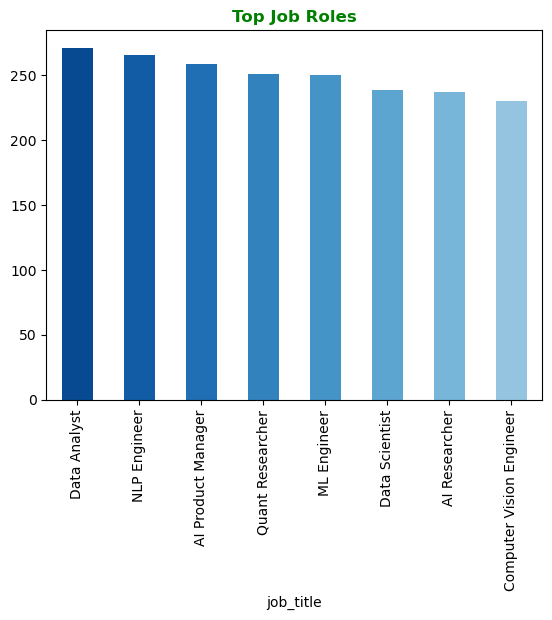

In [133]:
Top_roles = data['job_title'].value_counts().head(10)
                                                 
colors = plt.cm.Blues(np.linspace(0.9, 0.4, len(Top_roles)))

Top_roles.plot(kind='bar', color=colors)

plt.title("Top Job Roles" , fontweight = "bold", color = 'Green')

plt.savefig("top_job_roles.png", dpi=300, bbox_inches='tight')

plt.show()

### Employeement Type Distribution

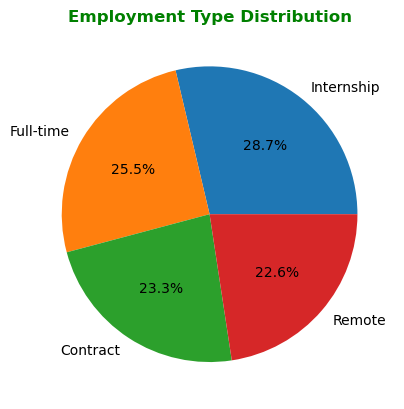

In [237]:
Employement_type = data['employment_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Employment Type Distribution", fontweight = 'bold', color = 'g')
plt.ylabel('')
plt.savefig("Employement_type.png",dpi=300, bbox_inches='tight')
plt.show()

### Salary Correlation

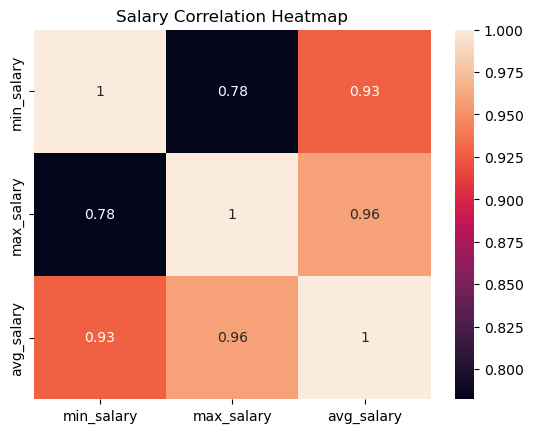

In [256]:
corr = data[['min_salary','max_salary','avg_salary']].corr()

sns.heatmap(corr, annot=True)
plt.title("Salary Correlation Heatmap")
plt.savefig("corr.png",dpi=300, bbox_inches='tight')
plt.show()

### Top 10 Skills in Demand

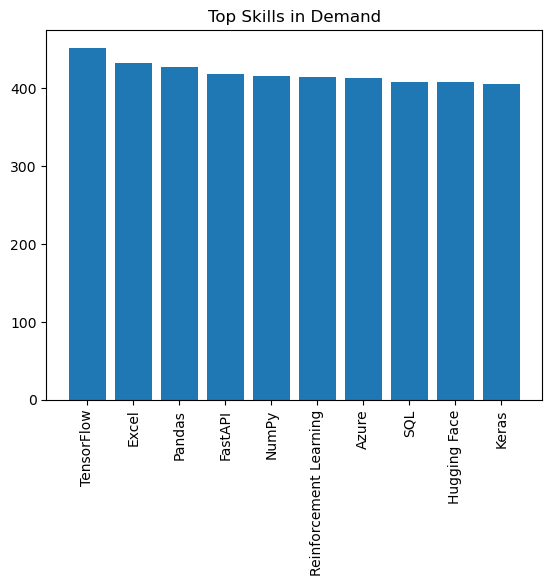

In [261]:
from collections import Counter

skills = data['skills_required'].dropna().str.split(',')
all_skills = [s.strip() for sublist in skills for s in sublist]

top_skills = dict(Counter(all_skills).most_common(10))

plt.bar(top_skills.keys(), top_skills.values())
plt.xticks(rotation=90)
plt.title("Top Skills in Demand")
plt.savefig("skills.png",dpi=300, bbox_inches='tight')

plt.show()

### Avg Salary By Insustry

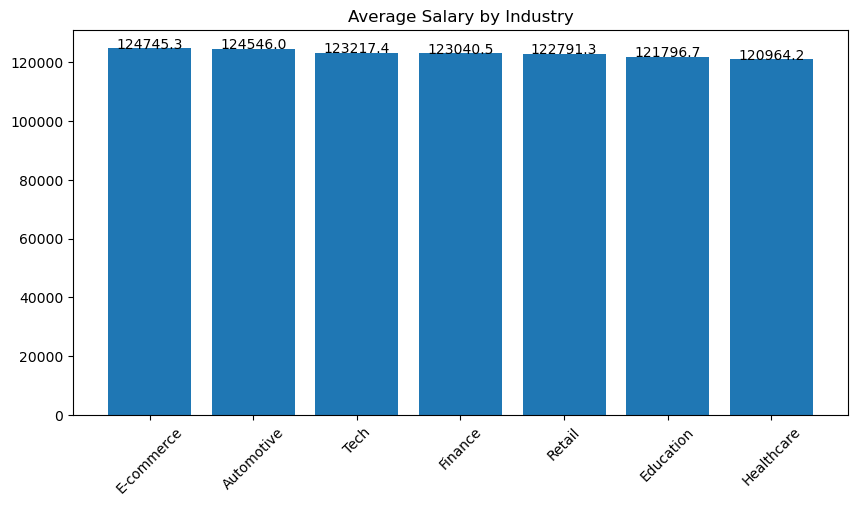

In [263]:
industry_salary = data.groupby('industry')['avg_salary'].mean().sort_values(ascending=False)

industry_salary

plt.figure(figsize=(10,5))

plt.bar(industry_salary.index, industry_salary.values)

plt.xticks(rotation=45)
plt.title("Average Salary by Industry")

# Add values on top
for i in range(len(industry_salary)):
    plt.text(i, industry_salary.values[i], round(industry_salary.values[i],1), ha='center')

plt.savefig("industry_salary.png",dpi=300, bbox_inches='tight')

plt.show()
